In [1048]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.special import jn_zeros

In [1049]:
geometry = "circle"

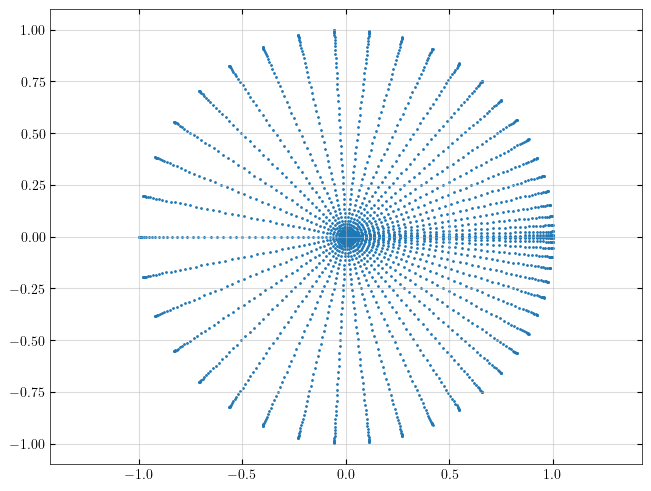

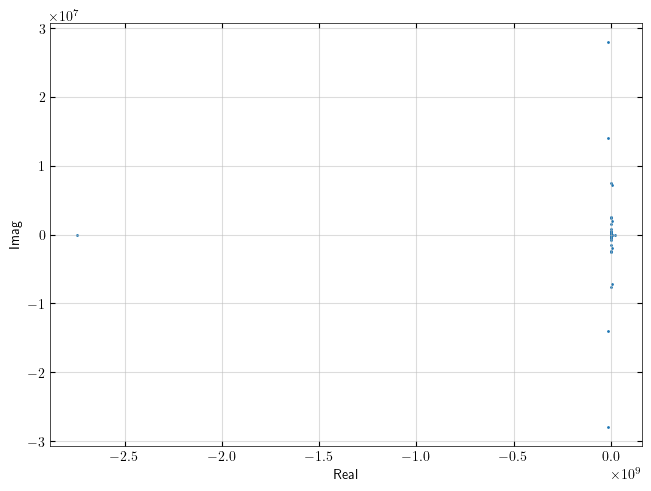

(2601, 2601)


In [1050]:
x = np.loadtxt(f"../results/{geometry}_x.csv")
y = np.loadtxt(f"../results/{geometry}_y.csv")
plt.scatter(x, y, s=1)
plt.axis('equal')
plt.show()

plt.figure()
plt.scatter(eigval_real, eigval_imag, s=1)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.show()

eigval_real = np.loadtxt(f"../results/{geometry}_eigval_real.csv")
eigval_imag = np.loadtxt(f"../results/{geometry}_eigval_imag.csv")
eigvec_real = np.loadtxt(f"../results/{geometry}_eigvec_real.csv", delimiter=",")
eigvec_imag = np.loadtxt(f"../results/{geometry}_eigvec_imag.csv", delimiter=",")

eigval = eigval_real + 1j*eigval_imag

if np.all(eigval_imag == 0):
    eigval = np.real(eigval)
    print("All eigenvalues real!")

eigvec = eigvec_real + 1j*eigvec_imag
amplitude = np.abs(eigvec)**2
print(eigvec.shape)

eigval_abs = np.abs(eigval)
idx = np.argsort(eigval_abs)
eigval_abs_sort = eigval_abs[idx]
eigvec_sort = eigvec[:, idx]
amplitude_sort = amplitude[:, idx]

In [1051]:
try: 
    A = np.loadtxt("../A.csv", delimiter = ",")
    B = np.loadtxt("../B.csv", delimiter = ",")
    print(A.shape)
    if A.shape[0] < 100:
        for row in A:
            print("".join("#" if x != 0 else "." for x in row))
            #print("".join(f"{x:.2f} " for x in row))

except:
    pass

print(f"Matrix A sparsity: {100*np.sum(A==0)/np.size(A):.4f}%")
print(f"Matrix B sparsity: {100*np.sum(B==0)/np.size(B):.4f}%")

(2601, 2601)
Matrix A sparsity: 96.3002%
Matrix B sparsity: 99.9645%


In [1052]:
if geometry == "square":
    L_x = max(x) - min(x)
    L_y = max(y) - min(y)
    exact = np.pi**2 * np.sort(np.array([(i/L_x)**2 + (j/L_y)**2 
                  for i in range(1, 100) for j in range(1, 100)]))
elif geometry == "semicircle":
    exact = np.sort(np.ravel([jn_zeros(n, 100)**2 for n in range(1, 100)]))
elif geometry == "circle":
    exact = np.sort(np.ravel(np.concatenate([
        [jn_zeros(0, 100)**2],
        [jn_zeros(n, 100)**2 for n in range(1, 100) for polarization in ["x", "y"]]])))

exact = exact[:len(eigval_abs_sort)]

rel_error = (eigval_abs_sort - exact) / exact

print("   Exact,       Numerical")
for i in range(40):
    print(f"{i}: {exact[i]:.6f}, {eigval_abs_sort[i]:.6f}")

   Exact,       Numerical
0: 5.783186, 5.783186
1: 14.681971, 14.681965
2: 14.681971, 14.681965
3: 26.374616, 26.374616
4: 26.374616, 26.374616
5: 30.471262, 30.471262
6: 40.706466, 40.706466
7: 40.706466, 40.706466
8: 49.218456, 49.218438
9: 49.218456, 49.218438
10: 57.582941, 57.582941
11: 57.582941, 57.582941
12: 70.849999, 70.849999
13: 70.849999, 70.849999
14: 74.887007, 74.887007
15: 76.938928, 76.938928
16: 76.938928, 76.938928
17: 95.277573, 95.277572
18: 95.277573, 95.277573
19: 98.726272, 98.726272
20: 98.726272, 98.726273
21: 103.499454, 103.499354
22: 103.499454, 103.499354
23: 122.427796, 122.427796
24: 122.427796, 122.427796
25: 122.907600, 122.907600
26: 122.907600, 122.907600
27: 135.020709, 135.020709
28: 135.020709, 135.020709
29: 139.040284, 139.040284
30: 149.452881, 149.452881
31: 149.452881, 149.452881
32: 152.241154, 152.241153
33: 152.241154, 152.241154
34: 169.395450, 169.395450
35: 169.395450, 169.395450
36: 177.520767, 177.520626
37: 177.520767, 177.520626
38

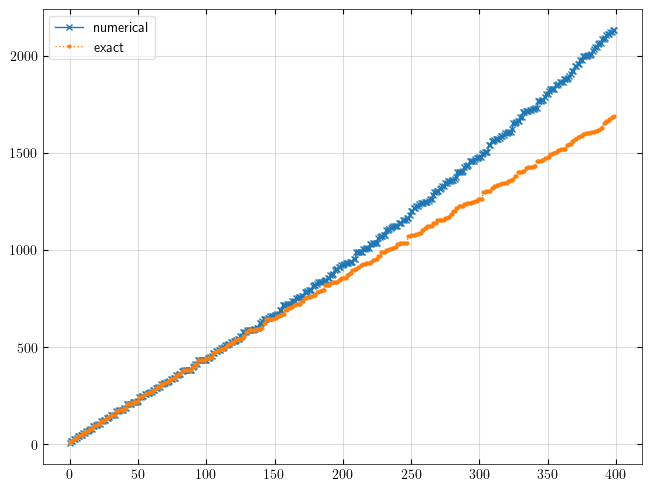

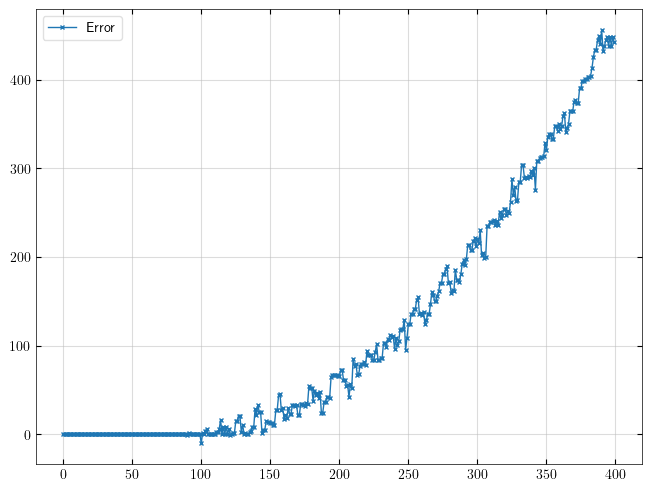

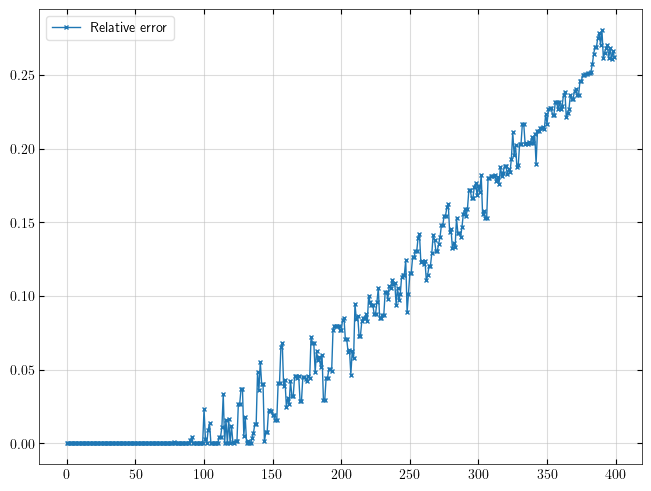

In [1053]:
xlim = 400 #len(eigval_abs)//3
log = False

plt.figure()
plt.plot(eigval_abs_sort[:xlim], marker='x', markersize=5, linewidth=1, label = "numerical")
plt.plot(exact[:xlim], marker = 'o', markersize = 2, linewidth=1, linestyle = ":", label = "exact")
plt.legend()

plt.figure()
plt.plot(eigval_abs_sort[:xlim] - exact[:xlim], marker='x', markersize=3, linewidth=1, label = 'Error')
if log:
    plt.yscale('log')
plt.legend()

plt.figure()
plt.plot(np.abs(rel_error[:xlim]), marker='x', markersize=3, linewidth=1, label = 'Relative error')
if log:
    plt.yscale('log')
plt.legend()

plt.show()

In [1054]:
def plot_interpolated(x, y, z):
    
    xi = np.linspace(min(x), max(x), 500)
    yi = np.linspace(min(y), max(y), 500)
    X_grid, Y_grid = np.meshgrid(xi, yi)
    
    Z = griddata(
        (x, y),
        z,
        (X_grid, Y_grid),
        method='cubic'
    )
    
    plt.contourf(X_grid, Y_grid, Z, levels=20)
    plt.colorbar(label='Amplitude')
    plt.scatter(x, y, c='k', alpha = 0.5, s=1) # Show actual data points
    

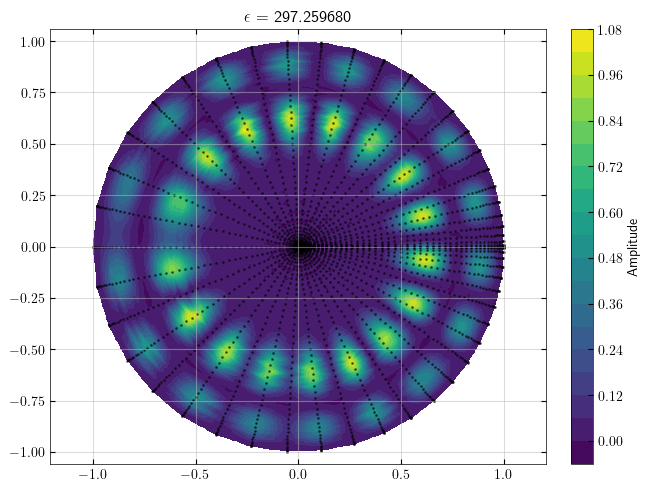

In [1059]:
i = 65
psi2 = amplitude_sort[:,i]

plot_interpolated(x, y, psi2)
plt.title(rf"$\epsilon$ = {eigval_abs_sort[i]:.6f}")
plt.axis('equal')
plt.show()